# DVH Comparison Notebook (CT vs sCT)

Notebook-only workflow.
- `run_model_analysis_notebook(...)` for model-level metric summaries.
- `plot_case_classical_dvh(...)` for classical cumulative DVH curves (PTV/OAR) on one case.

In [4]:
from pathlib import Path
from dataclasses import dataclass
from typing import Sequence, Union
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat

@dataclass
class NotebookAnalysisResult:
    model_name: str
    out_dir: Path
    combined_df: pd.DataFrame
    roi_summary: pd.DataFrame
    case_summary: pd.DataFrame

def _find_project_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    for c in candidates:
        if (c / 'outputs' / 'dvh_results').exists() and (c / 'matlab').exists():
            return c
    return Path.cwd()

def _norm(name: str) -> str:
    s = str(name).lower().strip()
    out = []
    prev_us = False
    for ch in s:
        if ch.isalnum():
            out.append(ch)
            prev_us = False
        else:
            if not prev_us:
                out.append('_')
                prev_us = True
    return ''.join(out).strip('_')

def run_model_analysis_notebook(
    model_name: str,
    results_root: Union[str, Path, None] = None,
    output_root: Union[str, Path, None] = None,
    target_rois: Sequence[str] = ('kidney left', 'kidney_left'),
    metrics: Sequence[str] = ('mean', 'D_95', 'D_98', 'D_2', 'max'),
    save_csv: bool = True,
    save_figures: bool = False,
) -> NotebookAnalysisResult:
    root = _find_project_root()
    results_root = Path(results_root) if results_root is not None else (root / 'outputs' / 'dvh_results')
    output_root = Path(output_root) if output_root is not None else (root / 'outputs' / 'dvh_analysis')
    if not results_root.is_absolute():
        results_root = (root / results_root).resolve()
    if not output_root.is_absolute():
        output_root = (root / output_root).resolve()

    model_dir = results_root / model_name
    if not model_dir.exists():
        raise FileNotFoundError(f'Model folder not found: {model_dir}')

    target_norm = {_norm(x) for x in target_rois}
    merged_all = []

    for case_dir in sorted([p for p in model_dir.iterdir() if p.is_dir()]):
        ct_p = case_dir / 'dvh_metrics_ct.csv'
        sct_p = case_dir / 'dvh_metrics_sct.csv'
        dlt_p = case_dir / 'dvh_metrics_delta.csv'
        if not (ct_p.exists() and sct_p.exists() and dlt_p.exists()):
            continue

        ct = pd.read_csv(ct_p)
        sct = pd.read_csv(sct_p)
        dlt = pd.read_csv(dlt_p)

        keep = ['name'] + [m for m in metrics if m in ct.columns and m in sct.columns and m in dlt.columns]
        a = ct[keep].rename(columns={m: f'ct_{m}' for m in keep if m != 'name'})
        b = sct[keep].rename(columns={m: f'sct_{m}' for m in keep if m != 'name'})
        c = dlt[keep].rename(columns={m: f'delta_{m}' for m in keep if m != 'name'})

        m = a.merge(b, on='name').merge(c, on='name')
        m.insert(0, 'case', case_dir.name)
        m['roi_norm'] = m['name'].map(_norm)
        m['roi_type'] = m['roi_norm'].map(lambda x: 'PTV' if x in target_norm else 'OAR')

        for met in metrics:
            ccol = f'ct_{met}'
            scol = f'sct_{met}'
            pcol = f'delta_pct_{met}'
            if ccol in m.columns and scol in m.columns:
                denom = m[ccol].replace(0, pd.NA)
                m[pcol] = 100.0 * (m[scol] - m[ccol]) / denom

        merged_all.append(m)

    if not merged_all:
        raise RuntimeError(f'No complete DVH CSV triplets found for model: {model_name}')

    all_df = pd.concat(merged_all, ignore_index=True)
    roi_summary = all_df.groupby(['name', 'roi_type'], as_index=False).mean(numeric_only=True)
    case_summary = all_df.groupby(['case', 'roi_type'], as_index=False).mean(numeric_only=True)

    out_dir = output_root / model_name
    out_dir.mkdir(parents=True, exist_ok=True)

    if save_csv:
        all_df.to_csv(out_dir / 'dvh_combined_metrics.csv', index=False)
        roi_summary.to_csv(out_dir / 'dvh_summary_by_roi.csv', index=False)
        case_summary.to_csv(out_dir / 'dvh_summary_by_case.csv', index=False)

    for met in metrics:
        dcol = f'delta_{met}'
        if dcol not in all_df.columns:
            continue
        plot_df = all_df[['name', dcol]].dropna()
        if plot_df.empty:
            continue
        order = plot_df.groupby('name')[dcol].mean().sort_values(ascending=False).index
        fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(order))))
        data = [plot_df.loc[plot_df['name'] == roi, dcol].values for roi in order]
        ax.boxplot(data, vert=False, tick_labels=list(order))
        ax.axvline(0, color='k', linewidth=1)
        ax.set_title(f'sCT-CT delta: {met}')
        ax.set_xlabel(met)
        plt.tight_layout()
        if save_figures:
            fig.savefig(out_dir / f'delta_box_{met}.png', dpi=160)
        plt.show()

    return NotebookAnalysisResult(
        model_name=model_name,
        out_dir=out_dir,
        combined_df=all_df,
        roi_summary=roi_summary,
        case_summary=case_summary,
    )

def _load_case_dvh_curves(model_name: str, case_id: str, results_root: Union[str, Path, None] = None):
    root = _find_project_root()
    results_root = Path(results_root) if results_root is not None else (root / 'outputs' / 'dvh_results')
    if not results_root.is_absolute():
        results_root = (root / results_root).resolve()

    mat_path = results_root / model_name / case_id / 'dvh_eval.mat'
    if not mat_path.exists():
        raise FileNotFoundError(f'dvh_eval.mat not found: {mat_path}')

    data = loadmat(mat_path, squeeze_me=True, struct_as_record=False)
    results = data['results']

    def to_dict(dvh_arr):
        out = {}
        for item in np.atleast_1d(dvh_arr):
            name = str(item.name)
            out[_norm(name)] = {
                'name': name,
                'dose': np.asarray(item.doseGrid, dtype=float),
                'vol': np.asarray(item.volumePoints, dtype=float),
            }
        return out

    return to_dict(results.dvhRef), to_dict(results.dvhSynth), mat_path

def plot_case_classical_dvh(
    model_name: str,
    case_id: str,
    target_rois: Sequence[str] = ('kidney left', 'kidney_left'),
    exclude_oars: Sequence[str] = ('body', 'body trunc', 'skin'),
    max_oars: int = 8,
    results_root: Union[str, Path, None] = None,
):
    ref, sct, mat_path = _load_case_dvh_curves(model_name, case_id, results_root=results_root)

    target_norm = {_norm(x) for x in target_rois}
    exclude_norm = {_norm(x) for x in exclude_oars}

    common = [k for k in ref.keys() if k in sct]
    ptv_keys = [k for k in common if k in target_norm]
    oar_keys = [k for k in common if (k not in target_norm and k not in exclude_norm)]

    if not ptv_keys:
        available = ', '.join(sorted([ref[k]['name'] for k in common]))
        raise ValueError(f'No target ROI found. target_rois={target_rois}. Available={available}')

    oar_keys = sorted(oar_keys)[:max_oars]

    def _differential_dvh(dose: np.ndarray, vol: np.ndarray) -> np.ndarray:
        if dose.size < 2:
            return np.zeros_like(vol, dtype=float)
        # Cumulative DVH is typically decreasing; use -dV/dD for differential DVH.
        return -np.gradient(vol, dose)

    fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex='col')

    for k in ptv_keys:
        name = ref[k]['name']
        axes[0, 0].plot(ref[k]['dose'], ref[k]['vol'], '-', linewidth=2, label=f'{name} CT')
        axes[0, 0].plot(sct[k]['dose'], sct[k]['vol'], '--', linewidth=2, label=f'{name} sCT')
        axes[1, 0].plot(ref[k]['dose'], _differential_dvh(ref[k]['dose'], ref[k]['vol']), '-', linewidth=2, label=f'{name} CT')
        axes[1, 0].plot(sct[k]['dose'], _differential_dvh(sct[k]['dose'], sct[k]['vol']), '--', linewidth=2, label=f'{name} sCT')
    axes[0, 0].set_title(f'PTV Cumulative DVH | {case_id}')
    axes[0, 0].set_ylabel('Volume [%]')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend(fontsize=8)
    axes[1, 0].set_title(f'PTV Differential DVH | {case_id}')
    axes[1, 0].set_xlabel('Dose [Gy]')
    axes[1, 0].set_ylabel('dVolume/dDose [%/Gy]')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend(fontsize=8)

    if oar_keys:
        for k in oar_keys:
            name = ref[k]['name']
            axes[0, 1].plot(ref[k]['dose'], ref[k]['vol'], '-', linewidth=1.8, label=f'{name} CT')
            axes[0, 1].plot(sct[k]['dose'], sct[k]['vol'], '--', linewidth=1.8, label=f'{name} sCT')
            axes[1, 1].plot(ref[k]['dose'], _differential_dvh(ref[k]['dose'], ref[k]['vol']), '-', linewidth=1.8, label=f'{name} CT')
            axes[1, 1].plot(sct[k]['dose'], _differential_dvh(sct[k]['dose'], sct[k]['vol']), '--', linewidth=1.8, label=f'{name} sCT')
    axes[0, 1].set_title(f'OAR Cumulative DVH | {case_id}')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend(fontsize=7, ncol=1)
    axes[1, 1].set_title(f'OAR Differential DVH | {case_id}')
    axes[1, 1].set_xlabel('Dose [Gy]')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend(fontsize=7, ncol=1)

    plt.suptitle(f'DVH comparison (CT vs sCT): cumulative and differential \n {model_name}', fontsize=10)
    plt.tight_layout()
    plt.show()

    return {
        'ptv_rois': [ref[k]['name'] for k in ptv_keys],
        'oar_rois': [ref[k]['name'] for k in oar_keys],
        'source': str(mat_path),
    }


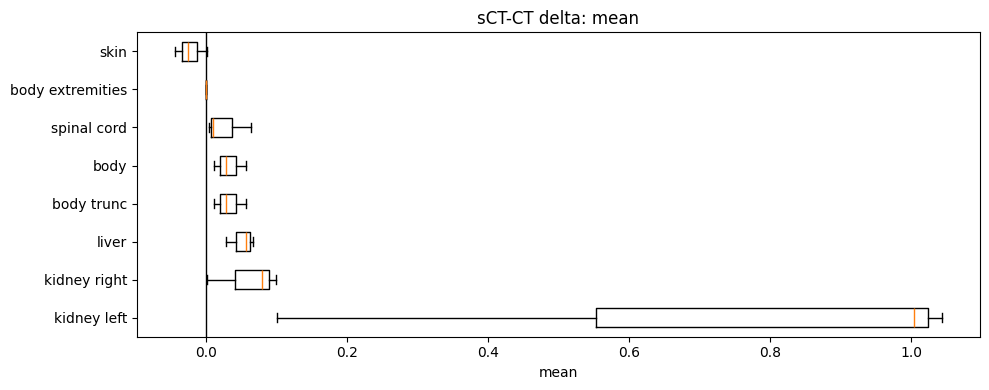

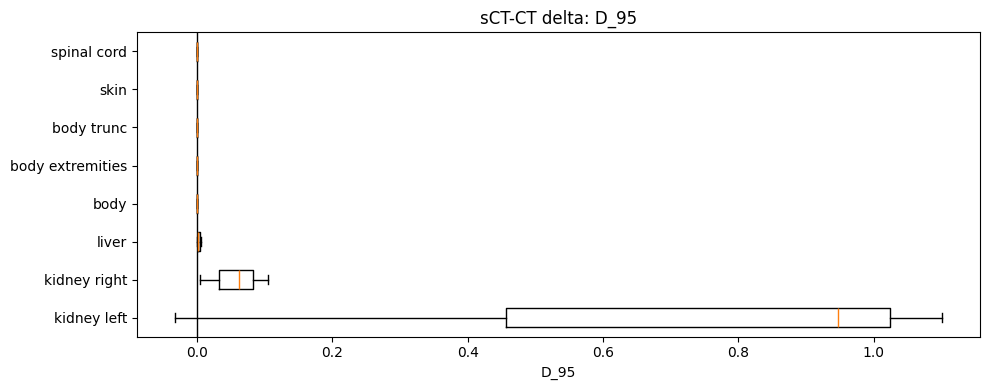

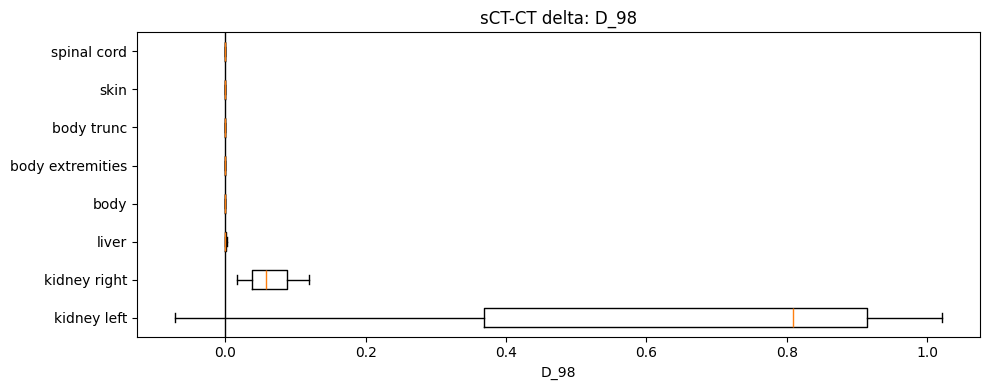

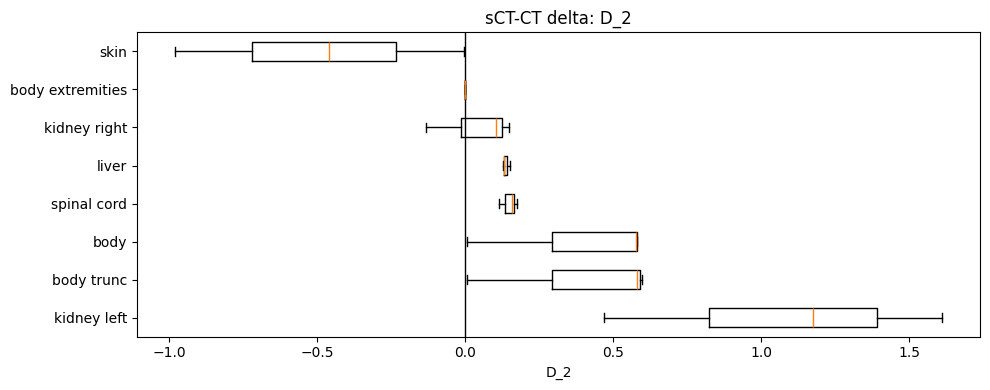

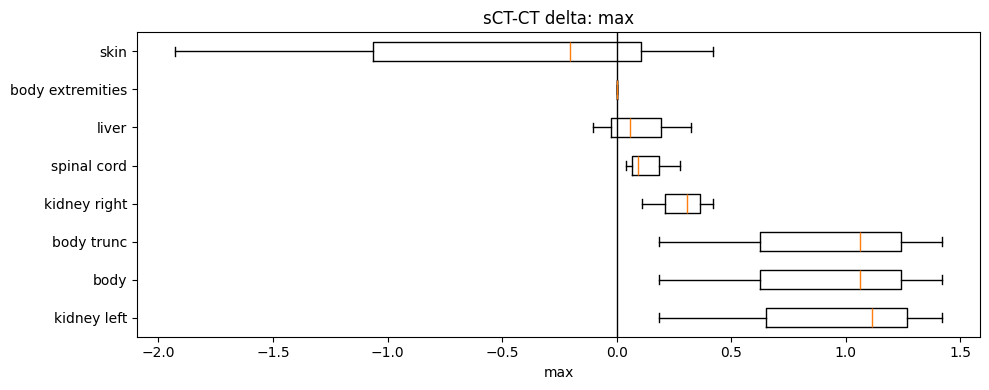

In [5]:
# 1-2 line usage for model-level metric summary
model_name = '2_experiment_cut_synthrad_abdomen_32p99'
result = run_model_analysis_notebook(model_name, save_csv=True, save_figures=False)

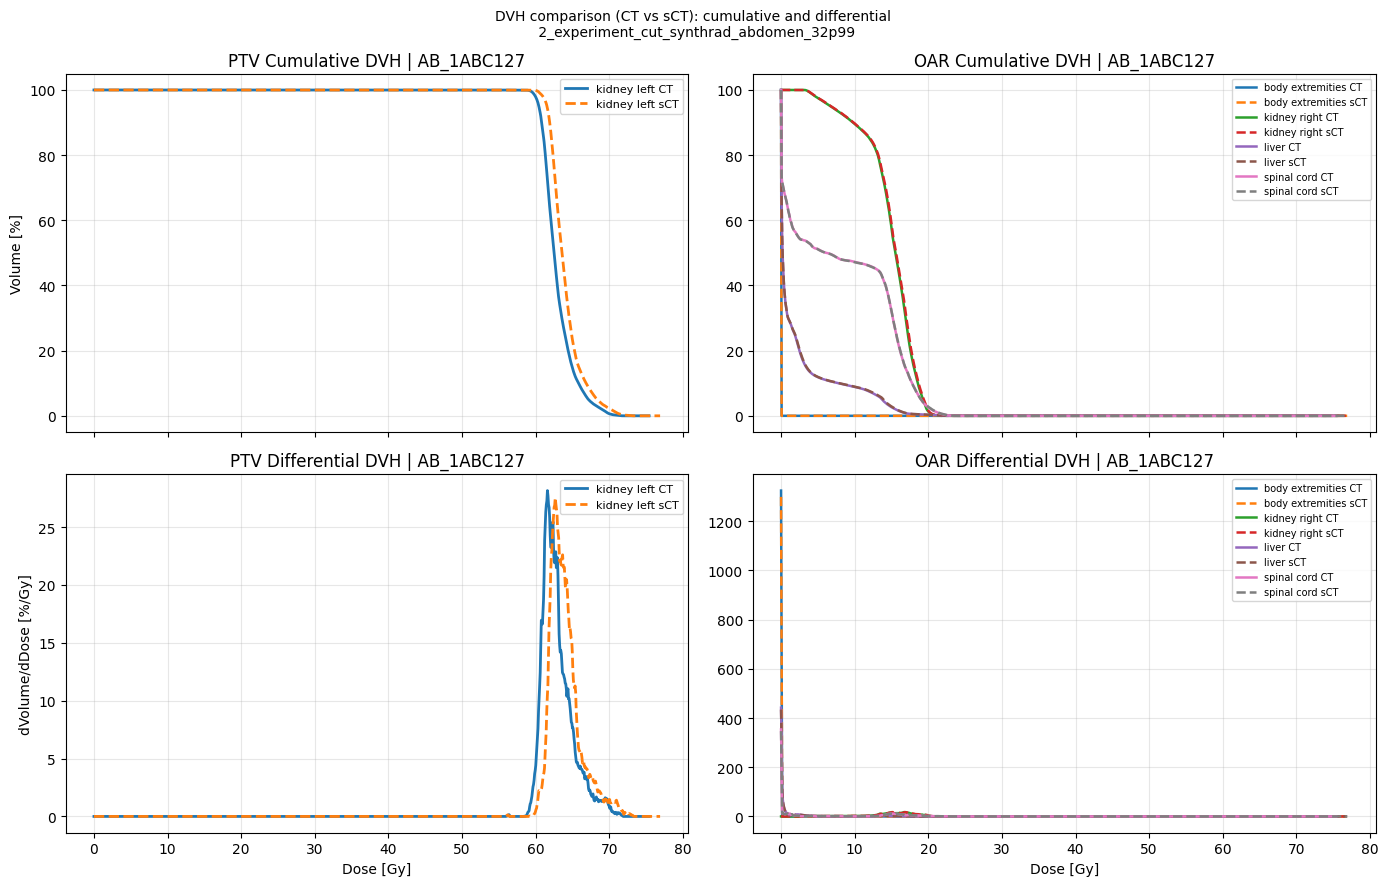

{'ptv_rois': ['kidney left'],
 'oar_rois': ['body extremities', 'kidney right', 'liver', 'spinal cord'],
 'source': '/Users/flavianthur/Documents/dvh/outputs/dvh_results/2_experiment_cut_synthrad_abdomen_32p99/AB_1ABC127/dvh_eval.mat'}

In [6]:
# Classical cumulative DVH (PTV vs OAR) for one case
plot_info = plot_case_classical_dvh(
    model_name='2_experiment_cut_synthrad_abdomen_32p99',
    case_id='AB_1ABC127',
    target_rois=('kidney left',),
)
plot_info

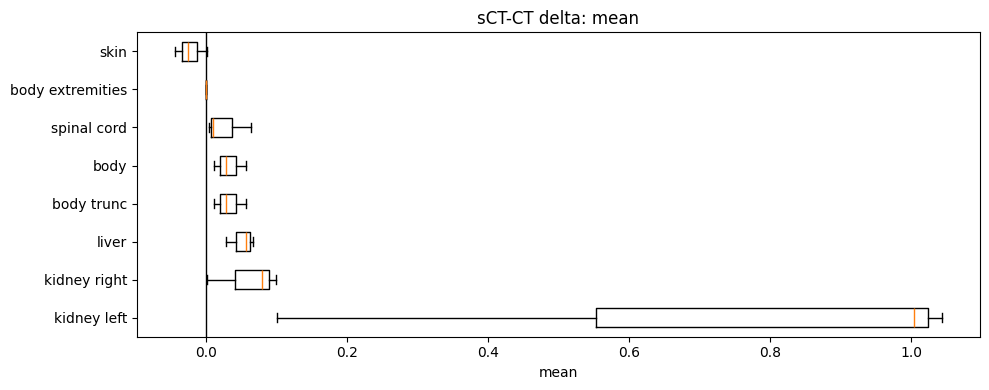

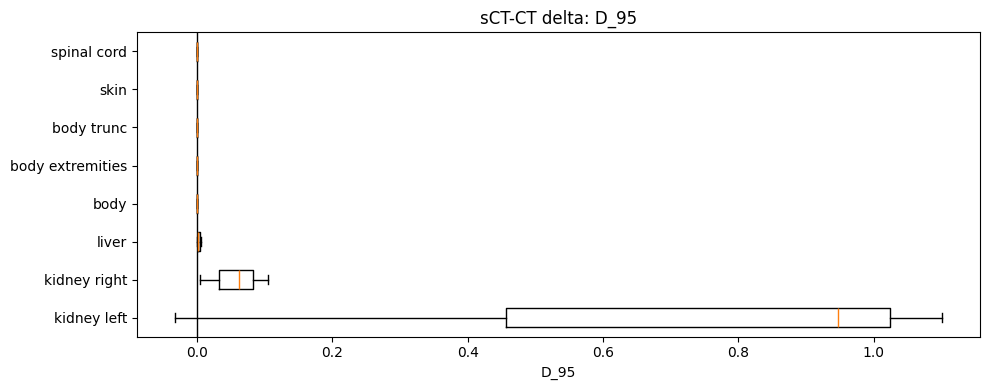

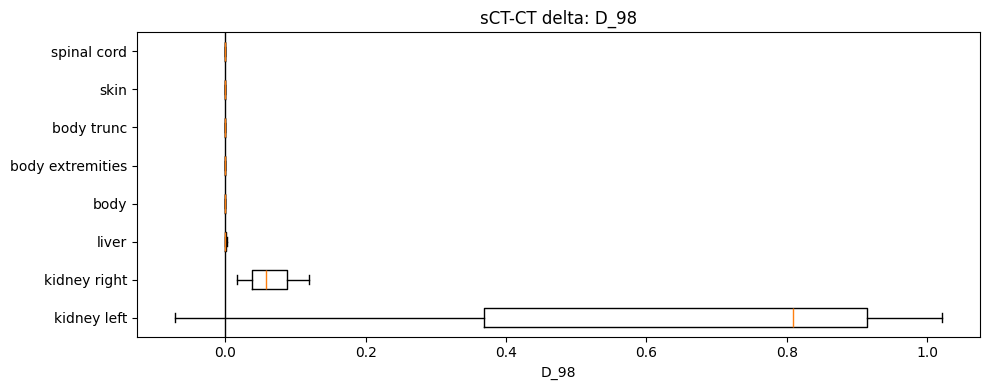

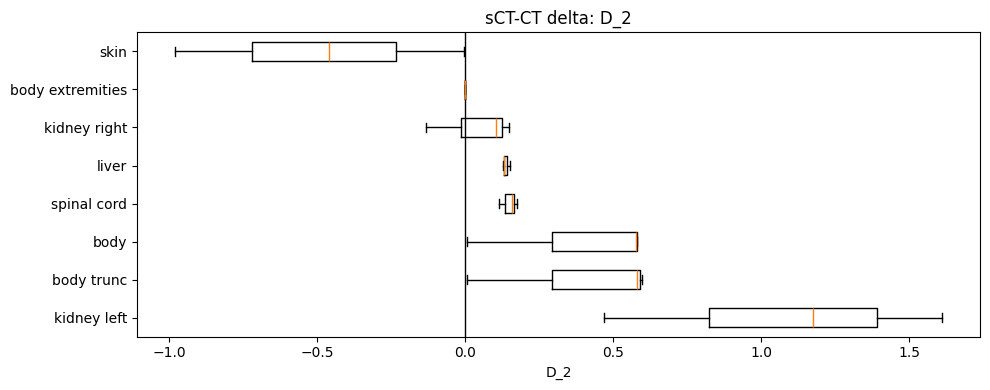

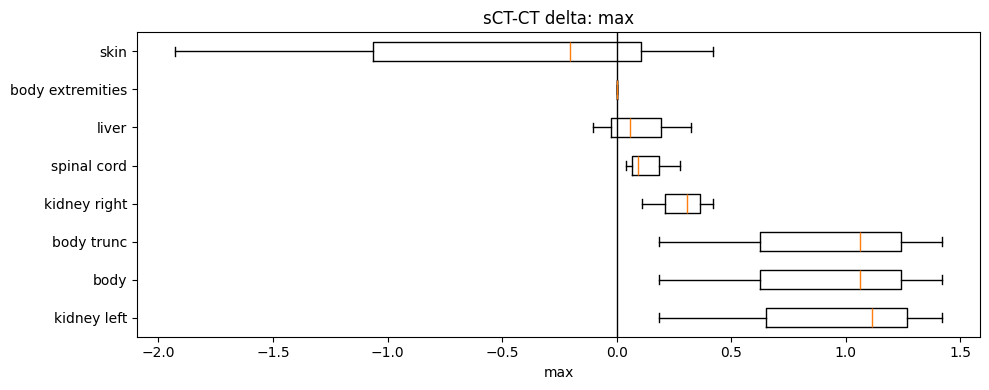

In [7]:
model_name = "2_experiment_cut_synthrad_abdomen_32p99"
result = run_model_analysis_notebook(model_name, save_csv=True, save_figures=False)